In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



Text(0, 0.5, 'Y dataset')

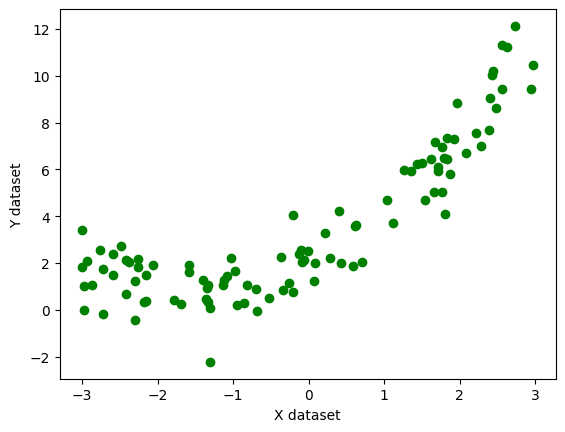

In [22]:
X= 6 * np.random.rand(100,1)-3
y = 0.5 * X ** 2 + 1.5*X + 2 + np.random.randn(100,1)

plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

regression_1.fit(X_train,y_train)

LinearRegression()

In [25]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.7184267895626517


Text(0, 0.5, 'Y dataset')

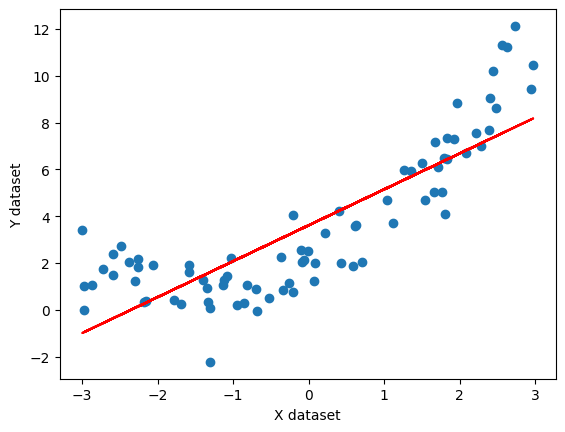

In [26]:
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [27]:
## apply polynomial transformation

from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
X_train_poly

array([[ 1.00000000e+00,  1.96867036e+00,  3.87566299e+00],
       [ 1.00000000e+00, -6.89266461e-01,  4.75088255e-01],
       [ 1.00000000e+00, -1.78699750e+00,  3.19336006e+00],
       [ 1.00000000e+00, -2.13434242e-01,  4.55541756e-02],
       [ 1.00000000e+00,  2.07955426e+00,  4.32454593e+00],
       [ 1.00000000e+00, -2.99908309e+00,  8.99449940e+00],
       [ 1.00000000e+00, -1.30382948e+00,  1.69997131e+00],
       [ 1.00000000e+00, -2.96880563e+00,  8.81380686e+00],
       [ 1.00000000e+00, -1.40344294e+00,  1.96965207e+00],
       [ 1.00000000e+00,  1.11507043e+00,  1.24338207e+00],
       [ 1.00000000e+00,  3.95104670e-01,  1.56107700e-01],
       [ 1.00000000e+00,  2.73088021e+00,  7.45770673e+00],
       [ 1.00000000e+00,  1.67741196e+00,  2.81371089e+00],
       [ 1.00000000e+00, -1.30637859e+00,  1.70662501e+00],
       [ 1.00000000e+00, -6.96894674e-01,  4.85662186e-01],
       [ 1.00000000e+00,  1.25603863e+00,  1.57763304e+00],
       [ 1.00000000e+00, -1.57894738e+00

In [28]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.9303137192625489


In [29]:
regression.coef_

array([[0.        , 1.56404472, 0.53075967]])

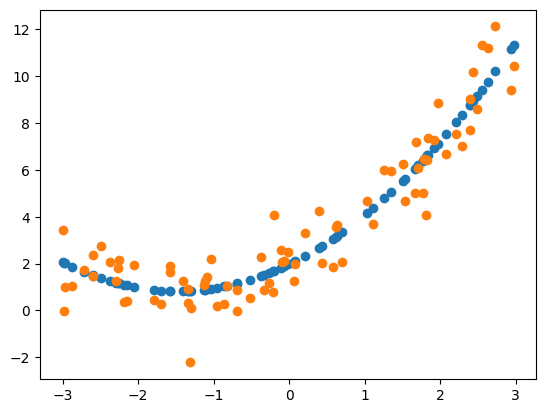

In [30]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [31]:
## prediction of new data

X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

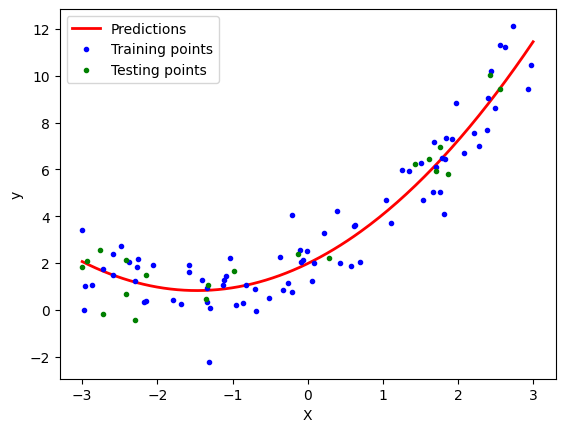

In [32]:
y_new=regression.predict(X_new_poly)
plt.plot(X_new,y_new,"r-",linewidth=2,label="Predictions")
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.",label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [33]:
from sklearn.pipeline import Pipeline
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()


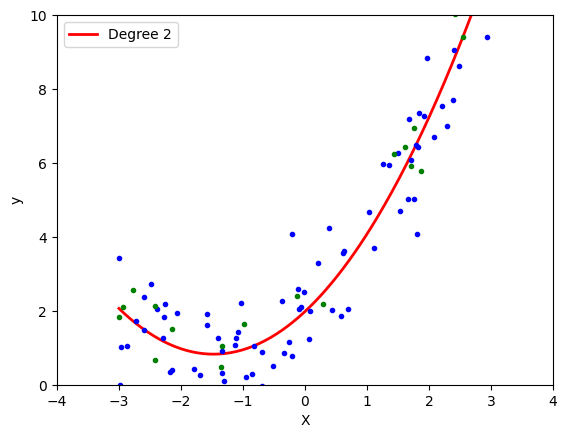

In [34]:
poly_regression(2)